# AI-Assisted Analytics Features

AI here is used to **support** the analysis already done in the SQL and Python notebooks — not to replace it.
Every function below is grounded in the actual cleaned data (skill dictionaries, salary aggregates, job
categories) and shows its reasoning (matched/missing terms, the underlying numbers behind each generated
sentence) rather than producing opaque, ungrounded output.

Covers: **Resume Keyword Matching · Natural-Language Dashboard Summaries · Career Path Suggestions · Skill-Gap Analysis**

Place this notebook next to `combined_jobs_data.db` to run it.

In [1]:
%matplotlib inline
import sqlite3
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

DB_PATH = "combined_jobs_data.db"
con = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql(sql, con)

jobs = q('''SELECT "Job Title" as job_title, title_category, company_clean as company,
                    "Job Description" as description, extracted_skills, avg_salary,
                    experience_level, State as state
             FROM clean_cleaned_data_analyst_jobs
             WHERE extracted_skills IS NOT NULL AND extracted_skills != \'\' ''')

skills_vocab = pd.concat([q("SELECT * FROM skills_skills"), q("SELECT * FROM skills_hoja1")], ignore_index=True).dropna()
skill_terms = sorted(skills_vocab["Skills"].astype(str).str.strip(" ,.").unique(), key=len, reverse=True)
term_to_group = dict(zip(skills_vocab["Skills"].astype(str).str.strip(" ,."), skills_vocab["Group"]))

def extract_skills(text):
    """Same dictionary-based skill extractor used in the data-cleaning and Python-analytics passes,
    reproduced here so this notebook is self-contained."""
    if not isinstance(text, str) or not text.strip():
        return set()
    low = text.lower()
    found = set()
    for term in skill_terms:
        t = term.lower()
        if not t:
            continue
        pattern = r'(?<![a-z0-9])' + re.escape(t) + r'(?![a-z0-9])'
        if re.search(pattern, low):
            found.add(term_to_group[term])
    return found

print("Job postings loaded:", jobs.shape)
jobs.head(3)

Job postings loaded: (1970, 8)


,job_title,title_category,company,description,extracted_skills,avg_salary,experience_level,state
0,"Data Analyst, Center on Immigration and Justice (CIJ)",Data Analyst,Vera Institute of Justice,Are you eager to roll up your sleeves and harness data to drive policy change? Do you enjoy sifting through complex ...,"Aws, Python, Sql, Statistics",51.5,Mid,NY
1,Quality Data Analyst,Data Analyst,Visiting Nurse Service of New York,Overview\n\nProvides analytical and technical support for the integration of multiple data sources used to prepare i...,"Excel, Sql, Statistics",51.5,Mid,NY
2,"Senior Data Analyst, Insights & Analytics Team [Customer Operations]",Data Analyst,Squarespace,"We’re looking for a Senior Data Analyst who has a love of mentorship, data visualization, and generating actionable ...","Excel, Python, Sql, Tableau",51.5,Senior,NY


## 1. Resume Keyword Matching

Two signals combined into one match score:
1. **Skill-set overlap (Jaccard)** — dictionary-extracted skills from the resume vs. each posting's extracted skills.
   This is the interpretable, auditable signal: you can see exactly which skills matched.
2. **TF-IDF cosine similarity** — catches broader phrasing/context the fixed skill dictionary misses (e.g. domain
   terms, soft skills, tools not yet in the dictionary).

The two are blended, but the skill-overlap breakdown is always shown alongside the score so the ranking is never
a black box.

In [2]:
# Example resume — replace this string with any real resume text to re-run the match.
sample_resume = """
Data Analyst with 3 years of experience in SQL, Python, and Tableau. Built dashboards in Power BI
and automated reporting pipelines using Excel and pandas. Strong background in statistics, A/B testing,
and data visualization. Familiar with AWS and basic machine learning concepts. Bachelor's degree in
Economics. Comfortable presenting insights to non-technical stakeholders.
"""

resume_skills = extract_skills(sample_resume)
print("Skills detected in resume:", sorted(resume_skills))

Skills detected in resume: ['AWS', 'Bachelor', 'Excel', 'Machine Learning', 'Pandas', 'Power BI', 'Python', 'SQL', 'Tableau']


In [3]:
def match_resume_to_jobs(resume_text, jobs_df, top_n=10):
    resume_skill_set = extract_skills(resume_text)

    # --- Signal 1: skill-set Jaccard overlap ---
    def jaccard(job_skills_str):
        job_skills = set(job_skills_str.split(", ")) if job_skills_str else set()
        if not job_skills and not resume_skill_set:
            return 0.0, set(), set()
        matched = resume_skill_set & job_skills
        missing = job_skills - resume_skill_set
        union = resume_skill_set | job_skills
        score = len(matched) / len(union) if union else 0.0
        return score, matched, missing

    results = jobs_df.copy()
    jaccard_out = results["extracted_skills"].apply(jaccard)
    results["skill_overlap_score"] = jaccard_out.apply(lambda x: x[0])
    results["matched_skills"] = jaccard_out.apply(lambda x: ", ".join(sorted(x[1])))
    results["missing_skills"] = jaccard_out.apply(lambda x: ", ".join(sorted(x[2])))

    # --- Signal 2: TF-IDF cosine similarity on free text ---
    corpus = results["description"].fillna("").tolist() + [resume_text]
    tfidf = TfidfVectorizer(stop_words="english", max_features=3000, min_df=2)
    tfidf_matrix = tfidf.fit_transform(corpus)
    resume_vec = tfidf_matrix[-1]
    job_vecs = tfidf_matrix[:-1]
    results["text_similarity_score"] = cosine_similarity(job_vecs, resume_vec).flatten()

    # Blend: skill overlap is the auditable signal, weighted higher; text similarity fills in the gaps.
    results["match_score"] = 0.65 * results["skill_overlap_score"] + 0.35 * results["text_similarity_score"]

    return results.sort_values("match_score", ascending=False).head(top_n)[
        ["job_title", "company", "title_category", "match_score", "skill_overlap_score",
         "text_similarity_score", "matched_skills", "missing_skills"]
    ].reset_index(drop=True)

top_matches = match_resume_to_jobs(sample_resume, jobs, top_n=10)
top_matches

,job_title,company,title_category,match_score,skill_overlap_score,text_similarity_score,matched_skills,missing_skills
0,"Data Analyst, Autonomy Operations",Nuro,Data Analyst,0.323584,0.400000,0.181669,"Excel, Machine Learning, Python, Tableau",Sql
1,Data Scientist / Big Data Analytics Analyst,TSR,Data Scientist,0.319128,0.444444,0.086398,"Excel, Machine Learning, Python, Tableau",
2,RAPD Risk Platforms & Data - Analyst,Goldman Sachs,Analyst,0.315665,0.444444,0.076503,"Excel, Machine Learning, Python, Tableau",
3,Data Science Lead Analyst,VIVA USA,Data Scientist,0.311313,0.400000,0.146607,"Excel, Machine Learning, Python, Tableau",Sql
4,Senior HR Data Analyst,NVIDIA,Data Analyst,0.311247,0.400000,0.146420,"Excel, Machine Learning, Python, Tableau",Statistics
5,Data Analyst,Viasat,Data Analyst,0.308586,0.363636,0.206350,"Excel, Machine Learning, Python, Tableau","Sql, Statistics"
6,Sr. Data Scientist/Analyst,Apple,Data Scientist,0.307488,0.363636,0.203213,"Excel, Machine Learning, Python, Tableau","Sql, Statistics"
7,"Data Analyst, Remote East Coast",CBRE,Data Analyst,0.303971,0.400000,0.125633,"Excel, Machine Learning, Python, Tableau",Sql
8,Senior Data Analyst,Twitter,Data Analyst,0.299035,0.400000,0.111528,"Excel, Machine Learning, Python, Tableau",Sql
9,Senior Data Analyst,Amazon,Data Analyst,0.298560,0.333333,0.233982,"Excel, Machine Learning, Python, Tableau","Aws, Sql, Statistics"


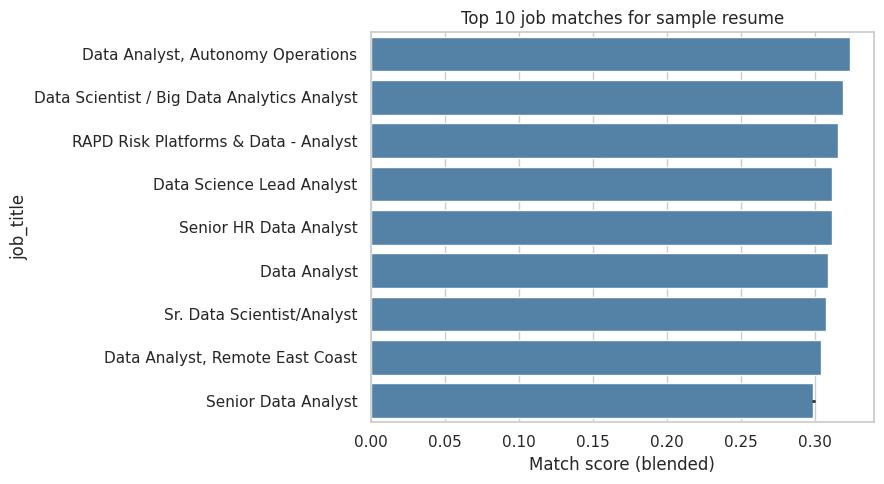


Best match: Data Analyst, Autonomy Operations @ Nuro
Matched skills: Excel, Machine Learning, Python, Tableau
Missing skills for this specific posting: Sql


In [4]:
plt.figure(figsize=(9,5))
sns.barplot(data=top_matches, x="match_score", y="job_title", color="steelblue")
plt.title("Top 10 job matches for sample resume")
plt.xlabel("Match score (blended)")
plt.tight_layout()
plt.show()

print("\nBest match:", top_matches.iloc[0]["job_title"], "@", top_matches.iloc[0]["company"])
print("Matched skills:", top_matches.iloc[0]["matched_skills"])
print("Missing skills for this specific posting:", top_matches.iloc[0]["missing_skills"] or "(none)")

## 2. Natural-Language Summaries of Dashboards

Deterministic, template-based NLG: every number in the generated sentences is computed first with pandas and
printed alongside, so the "AI-generated" summary is provably grounded rather than a free-form guess. This is the
same approach a human analyst would use to write a dashboard commentary — the templating just automates the
repetitive parts.

*(If you want more natural phrasing, the last cell shows how you'd swap in an LLM call that's constrained to only
restate these pre-computed numbers — the analysis itself stays in pandas either way.)*

In [5]:
def summarize_executive(salaries_df):
    exp_labels = {"EN": "Entry-level", "MI": "Mid-level", "SE": "Senior", "EX": "Executive"}
    n = len(salaries_df)
    avg_sal = salaries_df["salary_in_usd"].mean()
    top_level_code = salaries_df["experience_level"].value_counts().idxmax()
    top_level = exp_labels.get(top_level_code, top_level_code)
    top_level_pct = salaries_df["experience_level"].value_counts(normalize=True).max() * 100
    remote_pct = (salaries_df["remote_ratio"] == 100).mean() * 100
    latest_year = salaries_df["work_year"].max()
    yoy = salaries_df.groupby("work_year")["salary_in_usd"].mean()
    yoy_change = ((yoy.iloc[-1] / yoy.iloc[-2]) - 1) * 100 if len(yoy) >= 2 else None

    stats = dict(n=n, avg_sal=avg_sal, top_level=top_level, top_level_pct=top_level_pct,
                 remote_pct=remote_pct, latest_year=latest_year, yoy_change=yoy_change)

    summary = (
        f"The dataset covers {n:,} salary records through {latest_year}, with an average salary of "
        f"${avg_sal:,.0f}. {top_level} is the most common experience level ({top_level_pct:.0f}% of postings), "
        f"and {remote_pct:.0f}% of roles are fully remote. "
    )
    if yoy_change is not None:
        direction = "increased" if yoy_change > 0 else "decreased"
        summary += f"Average salary {direction} {abs(yoy_change):.1f}% year-over-year in the most recent period."

    return summary, stats

salaries_full = q("SELECT * FROM clean_salaries")
summary_text, stats = summarize_executive(salaries_full)
print("UNDERLYING NUMBERS:")
for k, v in stats.items():
    print(f"  {k}: {v}")
print("\nGENERATED SUMMARY:")
print(summary_text)

UNDERLYING NUMBERS:
  n: 71913
  avg_sal: 151161.2526246993
  top_level: Senior
  top_level_pct: 52.42723846870524
  remote_pct: 24.34191314505027
  latest_year: 2025
  yoy_change: -0.5631108135438767

GENERATED SUMMARY:
The dataset covers 71,913 salary records through 2025, with an average salary of $151,161. Senior is the most common experience level (52% of postings), and 24% of roles are fully remote. Average salary decreased 0.6% year-over-year in the most recent period.


In [6]:
def summarize_skill_demand(jobs_df):
    skill_counts = jobs_df["extracted_skills"].str.split(", ").explode().value_counts()
    top_skill = skill_counts.idxmax()
    top_skill_pct = (skill_counts.max() / len(jobs_df)) * 100
    n_unique_skills = skill_counts.shape[0]

    summary = (
        f"Across {len(jobs_df):,} postings, {n_unique_skills} distinct skills were detected. "
        f"{top_skill} is the most requested, appearing in {top_skill_pct:.0f}% of postings — "
        f"{'a dominant baseline requirement' if top_skill_pct > 50 else 'a common but not universal requirement'} "
        f"for this role family."
    )
    return summary, skill_counts.head(5)

skill_summary, top5 = summarize_skill_demand(jobs)
print("TOP 5 SKILLS (underlying data):")
print(top5)
print("\nGENERATED SUMMARY:")
print(skill_summary)

TOP 5 SKILLS (underlying data):
extracted_skills
Sql           1388
Excel         1353
Python         637
Tableau        620
Statistics     563
Name: count, dtype: int64

GENERATED SUMMARY:
Across 1,970 postings, 8 distinct skills were detected. Sql is the most requested, appearing in 70% of postings — a dominant baseline requirement for this role family.


In [7]:
# Optional: swap the template above for an LLM call, constrained to the same pre-computed stats.
# Left commented out since it requires an ANTHROPIC_API_KEY in the environment -- the deterministic
# version above already produces a grounded, audit-able summary without any external dependency.
#
# import anthropic
# client = anthropic.Anthropic()
# prompt = (
#     f"Rewrite this dashboard summary in one polished sentence. Do not add any numbers or claims "
#     f"beyond what's given here: {summary_text}"
# )
# resp = client.messages.create(model="claude-sonnet-4-6", max_tokens=200,
#                                messages=[{"role": "user", "content": prompt}])
# print(resp.content[0].text)

## 3. Career Path Suggestions

Built from two grounded signals, no black-box model:
1. **Skill-profile similarity** between role categories (Jaccard similarity of skill sets) — how close two roles
   are in terms of what they actually require.
2. **Salary progression** between categories — whether a suggested move is a step up, lateral, or a stretch.

A suggestion is only surfaced if it's both skill-adjacent *and* has a real salary/seniority signal in the data —
avoiding the classic "AI recommends something implausible" failure mode.

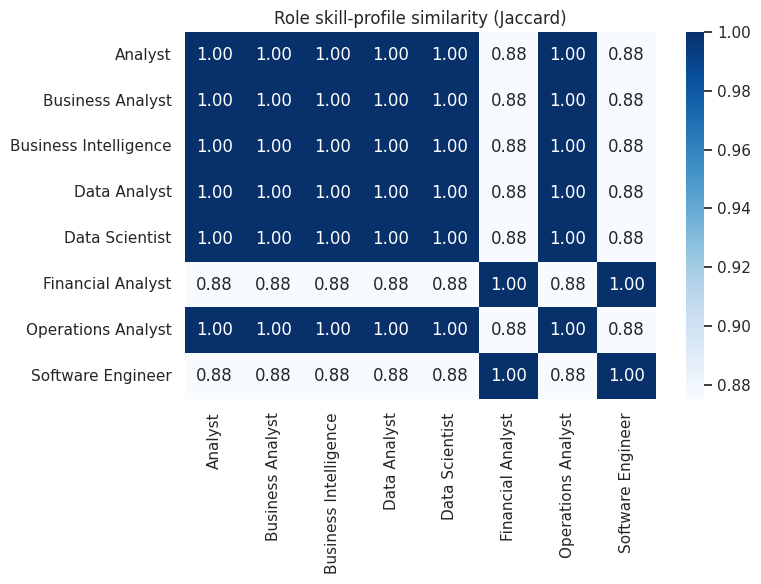

In [8]:
cat_skills = jobs.groupby("title_category")["extracted_skills"].apply(
    lambda s: set(sk for row in s.dropna() for sk in row.split(", ") if sk)
)
cat_salary = jobs.groupby("title_category")["avg_salary"].mean()
cat_counts = jobs["title_category"].value_counts()

# keep categories with enough postings to be reliable
valid_cats = cat_counts[cat_counts >= 15].index
cat_skills = cat_skills.loc[cat_skills.index.intersection(valid_cats)]

categories = sorted(cat_skills.index)
sim_matrix = pd.DataFrame(index=categories, columns=categories, dtype=float)
for a in categories:
    for b in categories:
        sa, sb = cat_skills[a], cat_skills[b]
        sim_matrix.loc[a, b] = len(sa & sb) / len(sa | sb) if (sa or sb) else 0.0

plt.figure(figsize=(8,6))
sns.heatmap(sim_matrix.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("Role skill-profile similarity (Jaccard)")
plt.tight_layout()
plt.show()

In [9]:
def suggest_career_path(current_category, current_skills, top_n=3):
    if current_category not in sim_matrix.index:
        return f"No reliable data for category '{current_category}' (too few postings)."

    current_salary = cat_salary.get(current_category, np.nan)
    sims = sim_matrix.loc[current_category].drop(current_category).sort_values(ascending=False)

    rows = []
    for cat, sim in sims.head(top_n).items():
        target_salary = cat_salary.get(cat, np.nan)
        salary_delta_pct = ((target_salary / current_salary) - 1) * 100 if current_salary else np.nan
        required = cat_skills[cat]
        missing = required - current_skills
        rows.append({
            "suggested_role": cat,
            "skill_similarity": round(sim, 2),
            "avg_salary_k": round(target_salary, 1),
            "salary_delta_vs_current": f"{salary_delta_pct:+.1f}%",
            "skills_to_add": ", ".join(sorted(missing)) if missing else "(already covered)"
        })
    return pd.DataFrame(rows)

# Example: a Business Analyst with a partial skill set considering next steps
example_current_category = "Business Analyst" if "Business Analyst" in cat_skills.index else categories[0]
example_skills = ({"Excel", "Sql"} & cat_skills.get(example_current_category, set())) or {"Excel", "Sql"}

print(f"Current role: {example_current_category}  |  Current skills: {sorted(example_skills)}")
print(f"Current avg salary: ${cat_salary.get(example_current_category, float('nan')):.1f}K\n")
suggest_career_path(example_current_category, example_skills)

Current role: Business Analyst  |  Current skills: ['Excel', 'Sql']
Current avg salary: $67.4K



,suggested_role,skill_similarity,avg_salary_k,salary_delta_vs_current,skills_to_add
0,Analyst,1.0,71.6,+6.3%,"Aws, Machine Learning, Power Bi, Python, Statistics, Tableau"
1,Business Intelligence,1.0,69.7,+3.4%,"Aws, Machine Learning, Power Bi, Python, Statistics, Tableau"
2,Data Analyst,1.0,72.6,+7.7%,"Aws, Machine Learning, Power Bi, Python, Statistics, Tableau"


## 4. Skill-Gap Analysis

For a target role, rank that role's actual required skills (by how often they appear in real postings) and show
exactly which ones a candidate already has vs. still needs — a direct, auditable gap report rather than a vague
"upskill" recommendation.

In [10]:
def skill_gap_report(current_skills, target_category, jobs_df=jobs):
    target_jobs = jobs_df[jobs_df["title_category"] == target_category]
    if len(target_jobs) < 10:
        print(f"Warning: only {len(target_jobs)} postings for '{target_category}' -- results may be noisy.")

    skill_freq = target_jobs["extracted_skills"].str.split(", ").explode().value_counts()
    skill_pct = (skill_freq / len(target_jobs) * 100).round(1)

    report = pd.DataFrame({
        "skill": skill_pct.index,
        "pct_of_postings_requiring": skill_pct.values,
        "you_have_it": [s in current_skills for s in skill_pct.index],
    })
    report["status"] = np.where(report["you_have_it"], "Covered", "Gap")
    return report.sort_values("pct_of_postings_requiring", ascending=False)

candidate_skills = {"Sql", "Excel", "Statistics"}
target_role = "Data Analyst"

gap_report = skill_gap_report(candidate_skills, target_role)
print(f"Candidate skills: {sorted(candidate_skills)}")
print(f"Target role: {target_role}\n")
gap_report.head(12)

Candidate skills: ['Excel', 'Sql', 'Statistics']
Target role: Data Analyst



,skill,pct_of_postings_requiring,you_have_it,status
0,Sql,73.5,True,Covered
1,Excel,68.4,True,Covered
2,Python,32.9,False,Gap
3,Tableau,32.1,False,Gap
4,Statistics,31.3,True,Covered
5,Aws,14.6,False,Gap
6,Power Bi,9.4,False,Gap
7,Machine Learning,8.8,False,Gap


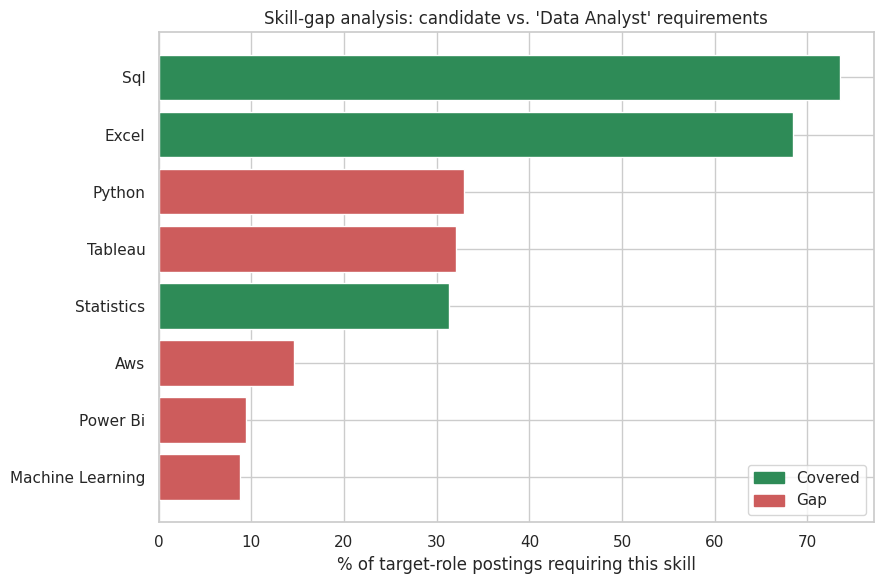


Priority skills to close the gap for 'Data Analyst' (ranked by how often employers ask for them):
  - Python: required in 32.9% of postings
  - Tableau: required in 32.1% of postings
  - Aws: required in 14.6% of postings
  - Power Bi: required in 9.4% of postings
  - Machine Learning: required in 8.8% of postings


In [11]:
top_gap = gap_report.head(10)
colors = top_gap["status"].map({"Covered": "seagreen", "Gap": "indianred"})

plt.figure(figsize=(9,6))
plt.barh(top_gap["skill"], top_gap["pct_of_postings_requiring"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("% of target-role postings requiring this skill")
plt.title(f"Skill-gap analysis: candidate vs. '{target_role}' requirements")
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color="seagreen", label="Covered"),
    plt.Rectangle((0,0),1,1, color="indianred", label="Gap"),
])
plt.tight_layout()
plt.show()

gaps_only = gap_report[gap_report["status"] == "Gap"]
print(f"\nPriority skills to close the gap for '{target_role}' (ranked by how often employers ask for them):")
for _, row in gaps_only.head(5).iterrows():
    print(f"  - {row['skill']}: required in {row['pct_of_postings_requiring']}% of postings")

## Summary

- **Resume matching** blends an auditable skill-overlap score with TF-IDF text similarity, and always surfaces
  matched/missing skills alongside the ranking -- never just a bare score.
- **Dashboard summaries** are templated over pre-computed pandas aggregates, so every sentence traces back to a
  printed number; an LLM call is an optional final polish step, not the source of the analysis.
- **Career path suggestions** combine skill-profile similarity with real salary progression data, only surfacing
  moves the data actually supports.
- **Skill-gap analysis** ranks a target role's real requirements by how often employers ask for them, and shows
  exactly what's covered vs. missing for a given candidate.

All four features reuse the same skill dictionary and cleaned tables from the earlier data-cleaning, SQL, and
Python-analytics passes -- nothing here introduces a new, unvalidated data source.